# COSY by STR method
## FIDs for COSY and P.COSY 2D spectra
### Author: John Price, jprice@qmagnetics.com

- For P.COSY see Marion and Bax, JMR 80 528-533 (1988)  
- For States-Haberkorn-Ruben method see Keeler p.230  
- This method requires 2 FIDs per t1 value. The P.COSY version has better line shapes on the diagonal.  
- STR provides frequency discrimination but it does not suppress T1 noise.

In [1]:
# Define the source path
SourcePath = '/media/HD2/Vineeth/PostDoc_Simulations/Github/PyOR_V1/PyOR_Combined/PyOR/Source_Doc'
#SourcePath = 'C:\\Users\\john\\Q Mag Code\\PyOR\\VThalakottoor-PyOR-120825\\Source_Doc'

# Add source path
import sys
sys.path.append(SourcePath)

import pickle
import time
import numpy as np
import sympy as sp

%matplotlib ipympl

# Import PyOR package
from PyOR_QuantumSystem import QuantumSystem as QunS
from PyOR_Hamiltonian import Hamiltonian
from PyOR_DensityMatrix import DensityMatrix
from PyOR_QuantumObject import QunObj
from PyOR_HardPulse import HardPulse
from PyOR_Basis import Basis
import PyOR_SignalProcessing as Spro
from PyOR_Plotting import Plotting
from PyOR_Evolution import Evolutions

### Set parameters

In [2]:
output_filename = 'COSY200Hz1000Hz_0p5_1p0a'   # without file extension

SW_1 = 200                 # spectral width (= 1/sampling period) for t1 (Hz)
SW_multiplier = 5          # spectral width multiplier, must be integer
SW_2 = SW_multiplier*SW_1  # spectral width for t2 and for template FID

t1_max = 0.5    # indirect dimension, longest t1 value (s)
t2 = 1.0        # direct dimension, acquisition time (s)

T1 = 1.0        # T1 (s)
T2 = 0.5        # T2 (s)

offset_A = 40   # chemical shift offsets (Hz)
offset_B = -10
J_AB = 5.0      # J coupling (Hz)

# Initialize the spin system
Spin_list = {"A" : "H1", "B" : "H1"}
QS = QunS(Spin_list, PrintDefault=False)
QS.Initialize()

# Offset Frequency in rotating frame (Hz)
QS.OFFSET["A"] = offset_A
QS.OFFSET["B"] = offset_B

# J coupling between spins (Hz)
QS.JcoupleValue("A","B",J_AB)

# B0 in TeslaZ
QS.B0 = 125.0/42.58

# Master equation
QS.PropagationSpace = "Hilbert"
QS.MasterEquation = "Redfield"
QS.OdeMethod = 'DOP853'
QS.PropagationMethod = "ODE Solver"

# Define initial and final Spin Temperature
QS.I_spintemp["A"] = 300.0
QS.I_spintemp["B"] = 300.0
QS.F_spintemp["A"] = 300.0
QS.F_spintemp["B"] = 300.0

# Relaxation Process
QS.Rprocess = "Phenomenological"
QS.R1 = 1/T1
QS.R2 = 1/T2

QS.Update()

Larmor Frequency in MHz:  [-124.99255023 -124.99250023]


### Generate Hamiltonians

In [3]:
# generate Larmor Frequencies
QS.print_Larmor = True
Ham = Hamiltonian(QS)
Hz = Ham.Zeeman_RotFrame()
Hj = Ham.Jcoupling()

Larmor Frequency in MHz:  [-124.99255023 -124.99250023]


## Product operator basis

In [4]:
BS = Basis(QS)
Index = False
Normal = True
Basis_Cart, dic_Cart = BS.ProductOperators_SpinHalf_Cartesian(Index,Normal)

## Initialize density matrix

In [5]:
DM = DensityMatrix(QS,Ham)

rho_initial = QS.Az + QS.Bz        # both spins polarized
rhoeq = QS.Az + QS.Bz
# rho_initial = QS.Az               # don't polarize B spin (for tests only)
# rhoeq = QS.Az

DM.DensityMatrix_Components(rho_initial,Basis_Cart,dic_Cart)

Density Matrix = 1.0 Id1 Iz2  + 1.0 Iz1 Id2 


## Excitation pulse

In [6]:
HardP = HardPulse(QS)
rho_0 = HardP.Rotate_Pulse(rho_initial, 90, QS.Ay+QS.By)  # phase of 0 --> x-axis
DM.DensityMatrix_Components(rho_0,Basis_Cart,dic_Cart)

Density Matrix = 1.0 Id1 Ix2  + 1.0 Ix1 Id2 


## Evolution: Generate Template FID and density matrix

In [7]:
# observables
det_Mt = QS.Ap + QS.Bp    # acquire complex FID
det_Mz = QS.Az + QS.Bz    # also track Mz

EVol = Evolutions(QS,Ham)
start_time = time.time()

# generate template rho and FID, use this for initial state before 2nd pulse
# will also use for P.COSY purge subtraction so need FID to the end of t2 for longest t1
dt2 = 1/SW_2           # sampling period in seconds
EVol.AcqFS = SW_2
EVol.AcqDT = dt2  
EVol.AcqAQ = t1_max + t2

t_template, rho_template = EVol.Evolution(rho_0,rhoeq,Hz+Hj)

_, FID_template = EVol.Expectation(rho_template,det_Mt)
_, Mz_template = EVol.Expectation(rho_template,det_Mz)

FID_template_90 = Spro.PhaseAdjust_FID(FID_template,90) # phase shifted template FID is needed for PCOSY

Larmor Frequency in MHz:  [-124.99255023 -124.99250023]


## Evolution: Generate FID arrays C and S after both pulses

In [8]:
# generate FID arrays C and S
# When t1 = 0 and both pulses have the same phase they combine to a pi pulse and the t2 FID is zero
# Thus pulse phases (0,0) yield S FIDs that are sine modulated along the indirect dimension
# Pulse phases (90,0) yield C FIDs are cosine modulated along the indirect dimension
EVol.AcqAQ = t2
Npoints_t2 = EVol.Compute_Npoints(EVol.AcqAQ,dt2) 
dt1 = 1/SW_1
Npoints_t1 = EVol.Compute_Npoints(t1_max,dt1) 

t1_array = EVol.Compute_Tpoints(Npoints_t1,dt1)# np.linspace(0,dt1*(Npoints_t1-1),Npoints_t1,endpoint=True)
t2_array = EVol.Compute_Tpoints(Npoints_t2,dt2)# np.linspace(0,dt2*(Npoints_t2-1),Npoints_t2,endpoint=True)

FID_array_C = np.zeros([Npoints_t1,Npoints_t2], dtype=complex)
FID_array_S = np.zeros([Npoints_t1,Npoints_t2], dtype=complex)
PFID_array_C = np.zeros([Npoints_t1,Npoints_t2], dtype=complex)
PFID_array_S = np.zeros([Npoints_t1,Npoints_t2], dtype=complex)

print('generating FIDs: ', end='')

for i in range(Npoints_t1):
    if (i+1)%10 == 0: print(f'.{i+1}',end='')                            # report progress
    rho_initial_0 = QunObj(rho_template[i*SW_multiplier])                # just before 2nd pulse, phase of 1st pulse was 0
    rho_initial_90 = HardP.Rotate_Pulse(rho_initial_0,90,QS.Az+QS.Bz)    # just before 2nd pulse, phase of 1st pulse was 90
    rho_initial_0_0 = HardP.Rotate_Pulse(rho_initial_0,90,QS.Ay+QS.By)   # after 2nd pulse, pulse phases were (0,0)
    rho_initial_90_0 = HardP.Rotate_Pulse(rho_initial_90,90,QS.Ay+QS.By) # after 2nd pulse, pulse phases were (90,0)

    _, rho_S = EVol.Evolution(rho_initial_0_0,rhoeq,Hz+Hj)               # evolve S and C density matrices
    _, rho_C = EVol.Evolution(rho_initial_90_0,rhoeq,Hz+Hj)

    # generate the FID arrays
    _, FID_array_S[i] = EVol.Expectation(rho_S,det_Mt)
    _, FID_array_C[i] = EVol.Expectation(rho_C,det_Mt)

    PFID_array_S[i,:] = FID_array_S[i,:] - FID_template[i*SW_multiplier:i*SW_multiplier+Npoints_t2]     # subtract template FID for PCOSY
    PFID_array_C[i,:] = FID_array_C[i,:] - FID_template_90[i*SW_multiplier:i*SW_multiplier+Npoints_t2]
    
print()
print(f'template FID length {FID_template.shape}, template time series length {len(t_template)}')
print(f'FID array S shape: {FID_array_S.shape}')
print(f'FID array C shape: {FID_array_C.shape}')

end_time = time.time()
time_taken = end_time - start_time
print("Total time = %s seconds " % (time_taken))

generating FIDs: .10.20.30.40.50.60.70.80.90.100
template FID length (1501,), template time series length 1501
FID array S shape: (101, 1001)
FID array C shape: (101, 1001)
Total time = 105.87519717216492 seconds 


## Save FID arrays 

In [9]:
COSY_FIDs = {}
COSY_FIDs['time_taken'] = time_taken
COSY_FIDs['offset_A'] = offset_A
COSY_FIDs['offset_B'] = offset_B
COSY_FIDs['J_AB'] = J_AB
COSY_FIDs['FID_template'] = FID_template
COSY_FIDs['FID_template_90'] = FID_template_90
COSY_FIDs['Mz_template'] = Mz_template
COSY_FIDs['t_template'] = t_template
COSY_FIDs['FID_array_S'] = FID_array_S
COSY_FIDs['FID_array_C'] = FID_array_C
COSY_FIDs['PFID_array_S'] = PFID_array_S
COSY_FIDs['PFID_array_C'] = PFID_array_C
COSY_FIDs['t1_array'] = t1_array
COSY_FIDs['t2_array'] = t2_array

file = open(output_filename + '.pickle', 'ab')
pickle.dump(COSY_FIDs, file)                    
file.close()

## Spectral Width

In [10]:
SW_template = 1/(t_template[1]-t_template[0])
SW_t1 = 1/(t1_array[1]-t1_array[0])
SW_t2 = 1/(t2_array[1]-t2_array[0])

Npoints = len(t_template)
Npoints_t1 = len(t1_array)
Npoints_t2 = len(t2_array)

print(f'spectral widths t1, t2, template: ({SW_t1}, {SW_t2}, {SW_template}) Hz')
print(f'template t points: {Npoints}, t1 points: {Npoints_t1}, t2 points: {Npoints_t2}')

spectral widths t1, t2, template: (200.0, 1000.0, 1000.0) Hz
template t points: 1501, t1 points: 101, t2 points: 1001


## Plotting

In [11]:
plot = Plotting(QS)

In [12]:
plot.PlotLinwidth = 1.0
plot.PlotFontSize = 20

## Plot template longitudinal magnetization

(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x7fbd3b2c2f90>)

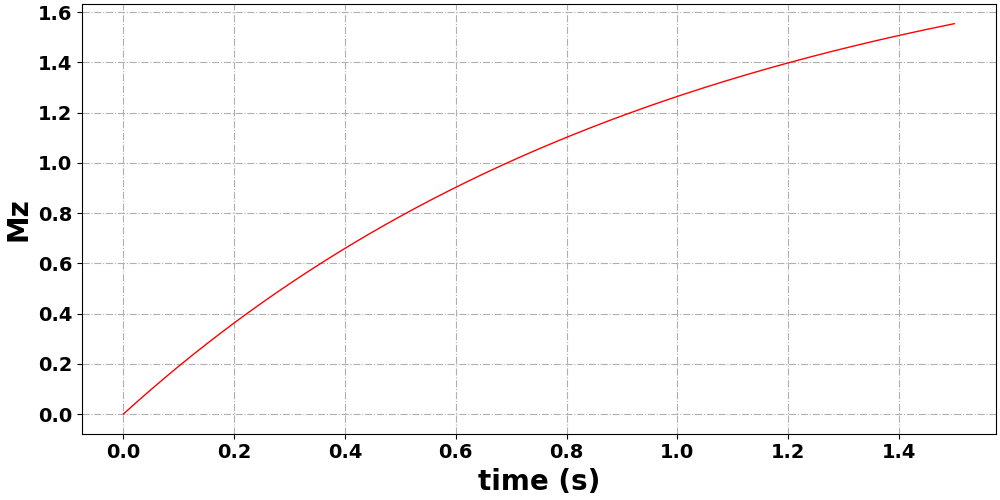

In [13]:
plot.PlotFigureSize = (10,5)
plot.Plotting_SpanSelector(t_template,Mz_template.real,"time (s)","Mz","red") 

## Plot template transverse magnetization 

(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x7fbd3af8af90>)

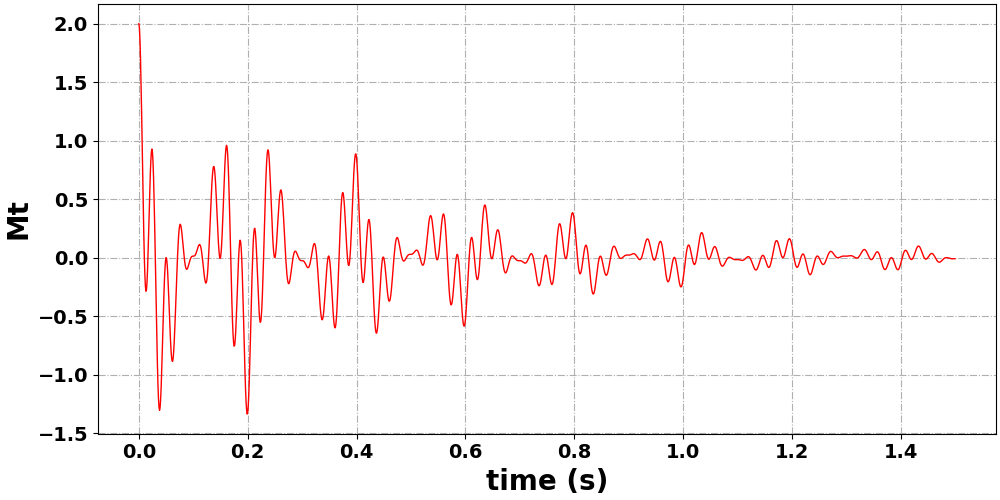

In [14]:
plot.PlotFigureSize = (10,5)
plot.Plotting_SpanSelector(t_template,FID_template.real,"time (s)","Mt","red") 

## Plot spectrum of template FID

In [15]:
zero_fill = 10 
freq, spectrum = Spro.FourierTransform(FID_template,SW_template,zero_fill)

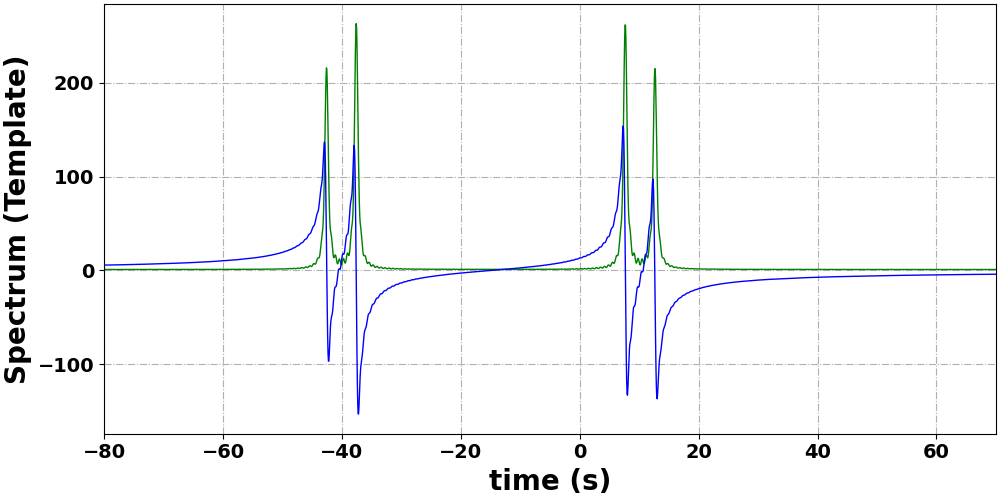

In [16]:
plot.PlotFigureSize = (10,5)
plot.PlotXlimt = (-80,70)
plot.PlottingMulti([freq,freq],[spectrum.real,spectrum.imag],"time (s)","Spectrum (Template)",["green","blue"])

## Plot 2D interferogram
Choose FID_array_S, FID_array_C, PFID_array_S, or PFID_array_C

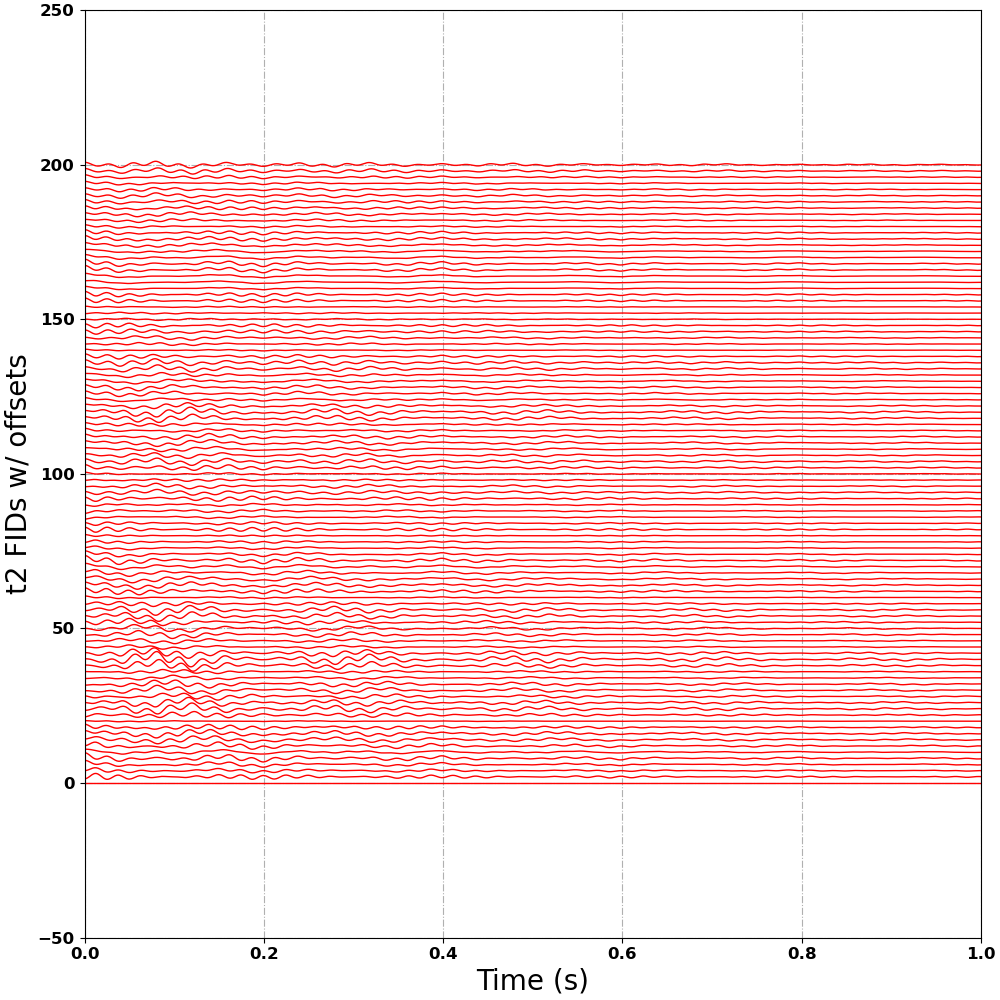

In [17]:
plot.PlotFigureSize = (10,10)
plot.PlotXlimt = (0,1)
plot.PlotYlimt = (-50,250)
plot.Plotting2DArray(t2_array, PFID_array_C,"Time (s)", "t2 FIDs w/ offsets", color="red", offset=2.0)

## Fourier transform over t2

In [18]:
#For COSY (skip this cell for P.COSY)
freqs_t2, Spectrum_over_t2 = Spro.FourierTransform2D_DirectDimension_COSY_STR(
    FID_array_C,
    FID_array_S,
    t1_array    = t1_array,
    t2_array    = t2_array,
    zero_fill   = 10,
    lb_t1       = 0.5,
    lb_t2       = 0.5,
    phase1_deg  = 0
)

In [19]:
#For P.COSY (skip this cell for COSY)
freqs_t2, Spectrum_over_t2 = Spro.FourierTransform2D_DirectDimension_COSY_STR(
    PFID_array_C,
    PFID_array_S,
    t1_array    = t1_array,
    t2_array    = t2_array,
    zero_fill   = 10,
    lb_t1       = 0.5,
    lb_t2       = 0.5,
    phase1_deg  = 0
)

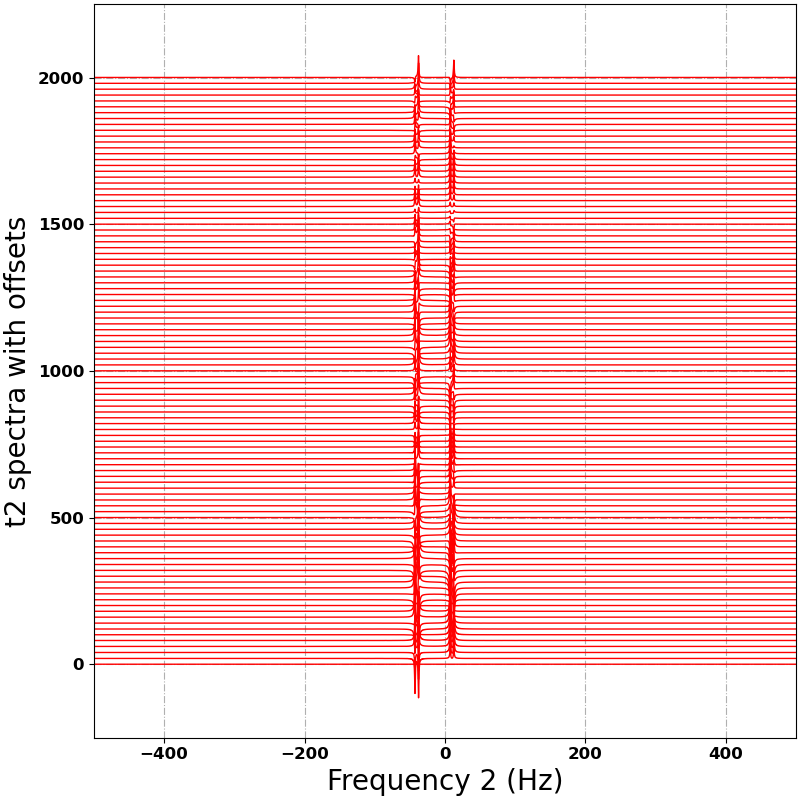

In [20]:
plot.PlotFigureSize = (8,8)
plot.PlotXlimt = (-500,500)
plot.PlotYlimt = (-250,2250)
plot.Plotting2DArray(freqs_t2, Spectrum_over_t2,"Frequency 2 (Hz)","t2 spectra with offsets", color="red", offset=20.0)

## 2D Spectrum

In [21]:
freqs_t1, Spectrum_2D = Spro.FourierTransform2D_IndirectDimension_COSY_STR(
    Spectrum_over_t2 = Spectrum_over_t2,
    t1_array         = t1_array,
    zero_fill        = 10,
    phase2_deg       = 90
)

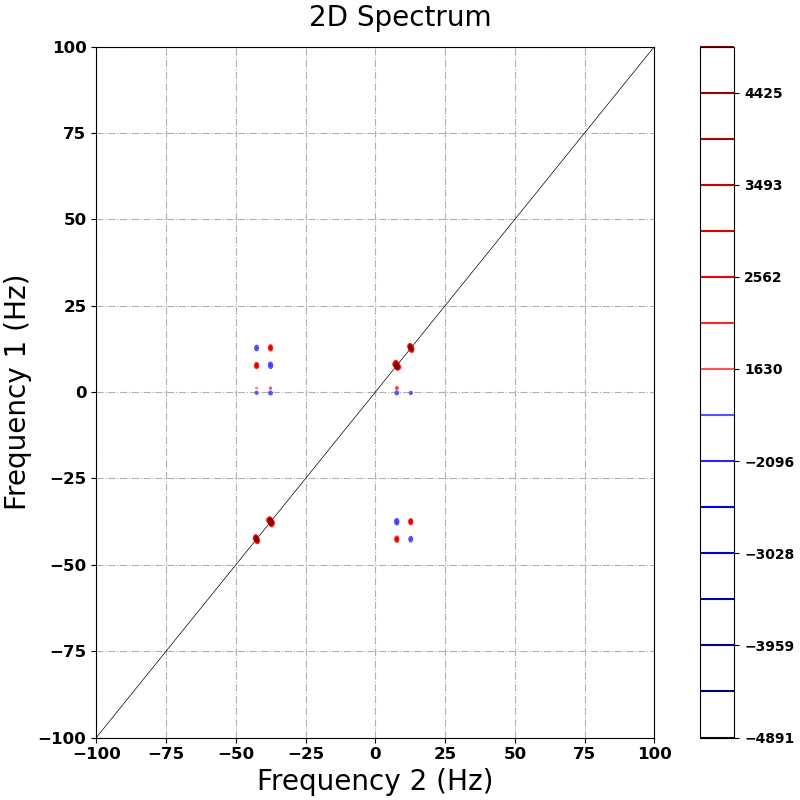

In [22]:
plot.PlotFigureSize = (8,8)
plot.PlotXlimt = (-SW_t1/2, SW_t1/2)
plot.PlotYlimt = (-SW_t1/2, SW_t1/2)
plot.PlottingContour_COSY(
    x=freqs_t2,
    y=freqs_t1,
    z=Spectrum_2D.real,
    xlab="Frequency 2 (Hz)",
    ylab="Frequency 1 (Hz)",
    title="2D Spectrum",
    nlevels=8,
    lift=2.5,
    scale=0.5
)